## Model evaluation
- Set up metric for each output
- Iterate over test loader and get outputs
- Calculate prediction for each output
- Update accuracy metrics
- Calculate final accuracy scores

In [ ]:
acc_alpha = Accuracy(
    task='multiclass', num_classes=30
)
acc_char = Accuracy(
    task='multiclass', num_classes=964
)

In [ ]:
net.eval()
with torch.no_grad():
    for images, labels_alpha, labels_char in dataloader_test:
        out_alpha, out_char = net(images)
        _, pred_alpha = torch.max(out_alpha, 1)
        _, pred_char = torch.max(out_char, 1)
        acc_alpha.update(pred_alpha, labels_alpha)
        acc_char.update(pred_char, labels_char)

In [ ]:
print(f'Alpha: {acc_alpha.compute()}')
print(f'Char: {acc_char.compute()}')

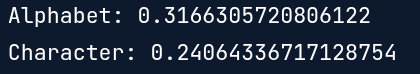

### Multi-output training loop (revisited)
- Two losses: for alphabets and characters
- final loss defined as sum of alphabet and character losses: `loss = loss_alpha + loss_char`
- Both classification tasks deemed equally IMPORTANT

In [ ]:
for epoch in range(10):
    for images, labels_alpha, labels_char in dataloader_train:
        optimizer.zero_grad()
        outputs_alpha, outputs_char = net(images)
        loss_alpha = criterion(
            outputs_alpha, labels_alpha
        )
        loss_char = criterion(
            outputs_char, labels_char
        )
        loss = loss_alpha + loss_char
        loss.backward()
        optimizer.step()

### Varying task importance
**Character classification 2 times more important than alphabet classification**
- Approach 1: Scale more important loss by a factor of 2
`loss = loss_alpha + loss_char * 2`
- Approach 2: Assign weights that sum to 1
`loss = 0.33 * loss_alpha + 0.67 * loss_char`

#### Warning: Losses on different scales
- Losses must be on the same scale before they are weighted and added
- Example tasks:
    - Predict house price -> MSE loss
    - Predict quality: low, medium, high -> CrossEntropy loss
- Crossentropy is typically in the single-digits
- MSE loss can reach tens of thousands
- Model would ignore quality assessment task
- Solution: Normalize both losses before weighting and adding


In [ ]:
loss_price = loss_price / torch.max(loss_price)
loss_quality = loss_quality / torch.max(loss_quality)
loss = 0.7 * loss_price + 0.3 * loss_quality